# Getting Started with TS-ICL — Imputation

[![arXiv](https://img.shields.io/badge/arXiv-2606.05878-b31b1b.svg)](https://arxiv.org/abs/2606.05878) [![PyPI](https://img.shields.io/pypi/v/tsicl.svg)](https://pypi.org/project/tsicl)

> **TS-ICL** is a probabilistic **Time Series Foundation Model** (TSFM) that unifies **forecasting** and **imputation** in a single zero-shot architecture, requiring no task-specific training.

This notebook focuses on the **imputation** use case: given a time series with missing values encoded as `NaN`, TS-ICL reconstructs them with **probabilistic predictions**.

### What you will learn
0. [Load the TS-ICL checkpoint](#loading-the-model)
1. [Run zero-shot imputation with pointwise and block missingness](#pointwise-block-missingness)
2. [Leverage exogenous covariates to sharpen imputation quality](#covariate-imputation)
3. [Leverage sparse exogenous covariates](#sparse-covariate-imputation)
4. [Interpret predictions — median, IQR bands, and empirical coverage](#output-format)
5. [Process multiple series efficiently via batch inference](#batch-processing)
6. [Tips & best practices](#tips-practices)

### Performance at a glance
On the `fm-impute-bench` benchmark (132 univariate tasks - 1.3M windows and 24 covariate-aware tasks):
- **+17% NMAE / +15% CRPS** over the best Tabular Foundation Model (TabICLv2-TS) in the univariate experiments
- **~50× faster** at inference — 6.5 ms per window on an H100 GPU
- With relevant covariates, an additional **~38% improvement** over the no-covariate variant

<div align="center">
  <img src="../contents/fm-impute-bench.png" alt="FM Impute Bench" width="75%" />
</div>

## Installation

In [ ]:
# Install the TS-ICL package (skip if already installed)
!pip install tsicl -q

## Imports

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from tsicl.pipeline import TSICL
from tsicl.plot.imputation import plot_sample_imputation

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  device: {device}")

: 

<a id="loading-the-model"></a>

## Loading the Model

The `tsicl-v1.ckpt` file contains two specialised TS-ICL checkpoints that share the same architecture but were trained on different tasks: one for imputation and the other for forecasting.

| Checkpoint | Training masking | Use case |
|---|---|---|
| **`imputation`** | Random pointwise + block masking, bidirectional context | Reconstruct missing values anywhere in the window |
| **`forecasting`** | Causal right-side masking only | Predict future values from a clean look-back |

Set `MODEL_PATH` to your downloaded checkpoint, or enable `allow_auto_download=True` for automatic fetching.

In [2]:
# ── Update this path to your local checkpoint ─────────────────────────────
MODEL_PATH = Path("../checkpoints/tsicl-v1.ckpt")

model = TSICL(
    model_path          = MODEL_PATH,
    allow_auto_download = False
)
print("✅  Model loaded")

✅  Model loaded


---
## Part 1 — Univariate and Covariate-Aware Imputation

<details>
<summary><strong>Architecture in brief</strong> ▸</summary>

TS-ICL processes each time series through four successive modules:

1. **Time Series Encoder** `𝓔` — a Perceiver-style architecture that compresses the observed (timestamp, value) pairs into M = 32 learnable latent tokens via cross-attention. It accepts inputs of arbitrary length without any preprocessing.
2. **Channel Mixer** `𝓜` — aggregates information across channels via cross-attention. In the univariate case this is a simple self attention operation; when covariates are present, it selectively integrates their latent representations into the target's representation.
3. **Temporal Context Query Module** `𝓒` — maps any query timestamp to a context-aware embedding using Fourier (NeRF-style) positional encoding + cross-attention. Querying at arbitrary timestamps is what makes the model naturally handle missing values and irregular grids.
4. **In-Context Regressor** `𝓡` — a causal Transformer that reads the observed (representation, value) pairs as "in-context training examples" and predicts quantiles at the target (missing) positions using causal self-attention.

<div align="center">
  <img src="../contents/TS-ICL-v1.png" alt="TS-ICL architecture" width="70%" />
</div>

</details>

### Key input convention

TS-ICL is designed to be highly flexible, supporting various time series structures and alignment conditions.

**(i) Supported Formats & Shapes**

We natively accept inputs as **NumPy arrays** or **Tensors** (e.g., PyTorch). 

| Input Type | Supported Shapes | Description |
| :--- | :--- | :--- |
| **Main Inputs** | `[T]` <br> `[T, N]` <br> `[T, N, 1]` | **T**: Number of observed time steps, **N**: Number of series (e.g. batch size). |
| **Covariates (`covars`)** | Same as inputs <br> *or* a `list` of arrays <br> *or* `[N, T', K]` |  **T'**: Number of time steps, **K**: Number of covariate features. <br>Can be structured matching the inputs, listed individually, or passed as a 3D tensor. |

**(ii) Missing Data & Alignment**
* **Partially Observed Covariates:** Covariates do **not** need to be fully observed.
* **Unaligned Inputs:** Main inputs do **not** strictly need to be perfectly aligned.

> ⚠️ **Note on Missing or Unaligned Data:** If your covariates are not fully observed or your inputs are not aligned, please refer to the tips section at the end of the notebook.

#### Use Case — Synthetic Dataset

We generate a 1 000-point signal using two **Gaussian Process** draws:
- **`daily_pattern`** — periodic at 24 h with a slow-varying envelope (ExpSineSquared × Matérn)
- **`weekly_pattern`** — periodic at 168 h with a slow-varying envelope (ExpSineSquared × Matérn)

The two components are added to form the target `signal`. Keeping them separate lets us later use `weekly_pattern` as a covariate — a clean analogue of real-world scenarios where a low-frequency exogenous driver (temperature, irradiance) is continuously observed.

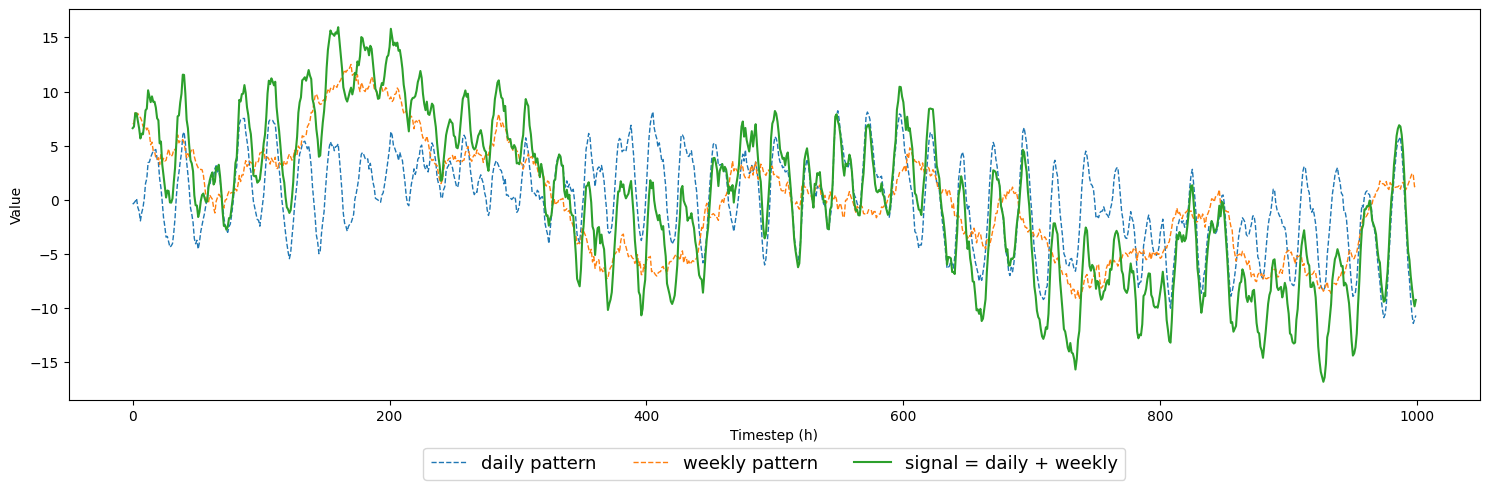

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ExpSineSquared, Matern

random_state = 91
np.random.seed(random_state)

T = 1000
t = np.arange(T, dtype=float).reshape(-1, 1)

# Daily pattern (period = 24 h)
kernel_daily  = ExpSineSquared(length_scale=1.5, periodicity=24.0) * Matern(length_scale=200.0, nu=0.5)
gp_daily      = GaussianProcessRegressor(kernel=kernel_daily, random_state=random_state)
daily_pattern = gp_daily.sample_y(t, random_state=random_state).flatten()
daily_pattern = 4.0 * (daily_pattern - daily_pattern.mean()) / daily_pattern.std()

# Weekly pattern (period = 168 h)
kernel_weekly  = ExpSineSquared(length_scale=3.0, periodicity=168.0) * Matern(length_scale=500.0, nu=0.5)
gp_weekly      = GaussianProcessRegressor(kernel=kernel_weekly, random_state=random_state)
weekly_pattern = gp_weekly.sample_y(t, random_state=random_state).flatten()
weekly_pattern = 5.0 * (weekly_pattern - weekly_pattern.mean()) / weekly_pattern.std()

signal = daily_pattern + weekly_pattern
t = t.flatten()   # reshape back to 1-D for plotting

plt.figure(figsize=(15, 5))
plt.plot(t, daily_pattern, "--", lw=1.0, label="daily pattern")
plt.plot(t, weekly_pattern, "--", lw=1.0, label="weekly pattern")
plt.plot(t, signal, lw=1.5, label="signal = daily + weekly")
plt.xlabel("Timestep (h)")
plt.ylabel("Value")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3, fontsize=13, frameon=True)
plt.tight_layout()
plt.show()

<a id="pointwise-block-missingness"></a>

### 1.1 Pointwise missingness (50%)

We randomly mask half the observations, simulating sensor dropouts or data-transmission errors. Each masked position will be independently imputed from the surrounding context.

In [4]:
missing_rate  = 0.50
mask_point    = np.random.random(T) < missing_rate     # True → missing

signal_masked = signal.copy()
signal_masked[mask_point] = np.nan

print(f"Missing: {mask_point.sum()} / {T}  ({100 * missing_rate:.0f}%)")

Missing: 522 / 1000  (50%)


The model accepts the masked signal directly — missing values are encoded as `NaN`, no separate mask tensor is needed.

`model.impute()` returns two tensors:
- **`batch_p`** — point estimate, shape `[N, C, T, 1]` (use `point_estimator='median'` or `'mean'`)
- **`batch_q`** — quantile predictions, shape `[N, C, T, Q]`

where `N` = batch size, `C` = number of channels (1 for univariate), `T` = window length, `Q` = number of requested quantile levels. Squeeze the channel dimension to get `[N, T, 1]` and `[N, T, Q]`.

Predictions are produced at **all** T timesteps — both observed and missing — so you can freely evaluate coverage at any subset of positions.

In [5]:
quantile_levels = [0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99]

batch_p, batch_q = model.impute(
    inputs          = signal_masked,         # 1-D numpy array of length T; [N,T,1] tensor also accepted
    batch_size      = 1,
    device          = device,
    quantile_levels = quantile_levels,
    point_estimator = "median",              # 'mean' is also available
    denormalize     = True                   # return predictions in the original scale
)
# batch_p (median estimation):  [T]
# batch_q (quantiles estimation): [T, Q]

pred_mean      = batch_p.cpu().numpy()    # [T, 1]
pred_quantiles = batch_q.cpu().numpy()    # [T, Q]

print(f"Point prediction shape   : {pred_mean.shape}")
print(f"Quantile prediction shape: {pred_quantiles.shape}")

Point prediction shape   : (1000,)
Quantile prediction shape: (1000, 13)


`plot_sample_imputation` is included in the TS-ICL package. It overlays the ground truth, the observed context points, the median prediction, and the requested IQR bands.

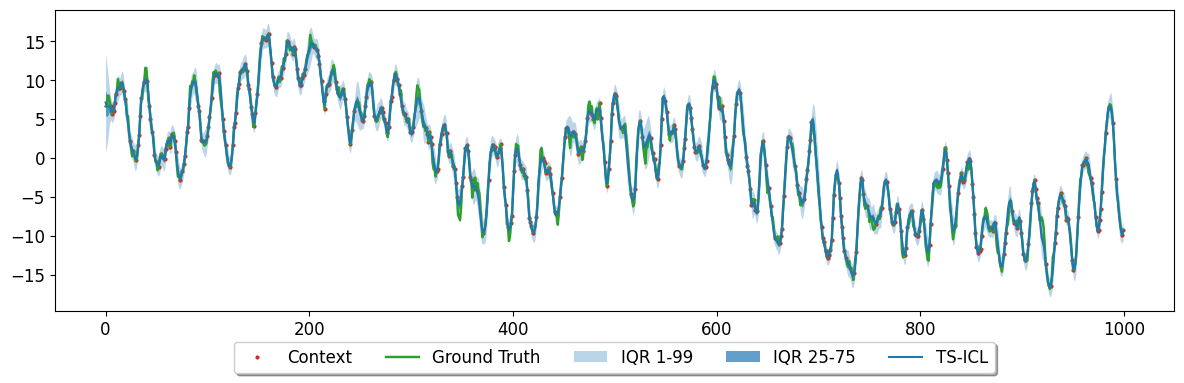

In [6]:
fig, ax = plot_sample_imputation(
    quantiles           = pred_quantiles,   # [T, Q]
    y_ctx               = signal_masked,
    y_true              = signal,
    show_context_points = True,
    quantile_levels     = quantile_levels,
    plot_iqr            = True,
    model_name          = "TS-ICL",
    iqr_bands           = ((0.01, 0.99), (0.25, 0.75))
)
plt.show()
plt.close()

### 1.2 Block missingness (two 100-point contiguous gaps)

Contiguous gaps arise from planned maintenance, device resets, or communication outages. In many energy datasets — for instance the `fm-impute-bench` evaluation — these are the dominant missingness pattern (up to four one-day gaps per four-week window).

The time-indexed formulation of TS-ICL handles block gaps natively: the encoder simply ignores the NaN positions, and the regressor predicts quantiles at each missing timestamp conditioned on the surrounding context. No code change is needed compared to the pointwise case.


Missing: 200 / 1000  (20.0%)


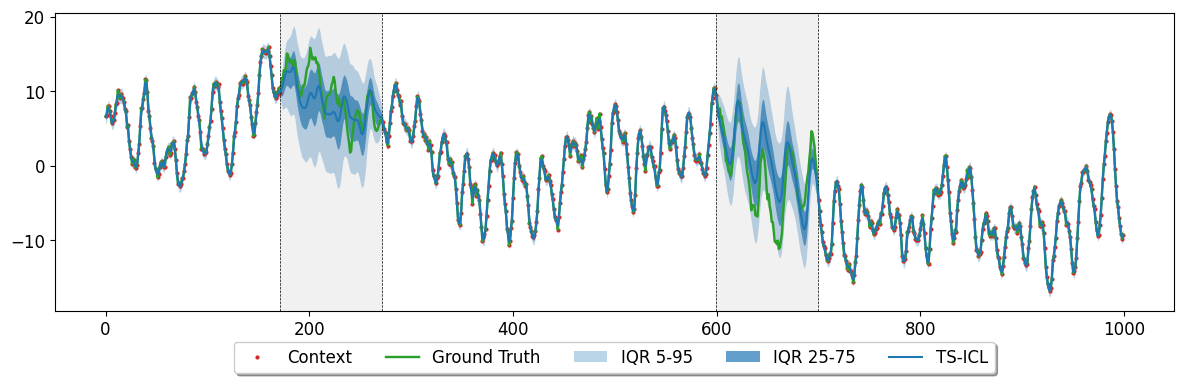

In [7]:
mask_block    = np.zeros(T, dtype=bool)
BLOCK_STARTS  = [172, 600]
for s_t in BLOCK_STARTS:
    mask_block[s_t : s_t + 100] = True

signal_block  = signal.copy()
signal_block[mask_block] = np.nan
print(f"Missing: {mask_block.sum()} / {T}  ({100 * mask_block.mean():.1f}%)")

_, batch_q_block = model.impute(
    inputs          = signal_block,          # 1-D numpy array, same as section 1.1
    batch_size      = 1,
    device          = device,
    quantile_levels = quantile_levels,
    denormalize     = True
)
pred_block_no_covar = batch_q_block.cpu().numpy()   # [T, Q]

fig, ax = plot_sample_imputation(
    quantiles           = pred_block_no_covar,
    y_true              = np.array(signal),
    y_ctx               = np.array(signal_block),
    show_context_points = True,
    quantile_levels     = quantile_levels,
    plot_iqr            = True,
    model_name          = "TS-ICL",
    is_blockwise        = True,
    iqr_bands           = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

<a id="covariate-imputation"></a>

---
### 1.3 Imputation with a Known Covariate

#### Why covariates matter

Many real-world sensors share an underlying physical driver: when one goes offline, its correlated neighbours keep recording. TS-ICL accepts any number of **exogenous time series** alongside the target and uses them to sharpen its predictions — without retraining.

Examples evaluated in the paper (French transmission-system operator data):

| Target | Covariate | Physical coupling |
|---|---|---|
| Wind-farm power output | Wind speed | Power ∝ wind³ |
| Solar PV production | Surface solar irradiance | Power ∝ irradiance |
| National electricity load | Mean outdoor temperature | Temperature significantly impacts electricity demand levels |

In each case the covariate is **fully observed** across the entire window — including during the target's missing blocks — providing the model with a precise low-frequency anchor.

#### Our example

Our `signal` is the sum of `daily_pattern` and `weekly_pattern`. During a 100-point (~4-day) gap, the daily context visible on each side of the gap leaves the low-frequency weekly phase ambiguous: the model cannot reliably tell where in the 168-h cycle the gap falls, leading to wide uncertainty bands and possible phase errors.

By supplying `weekly_pattern` as a **fully-observed covariate** — available across all 1 000 timesteps including the gap — we give the model a direct view of the weekly pattern. It can then focus its predictive effort on the daily fluctuations, producing sharper and more accurate estimates.

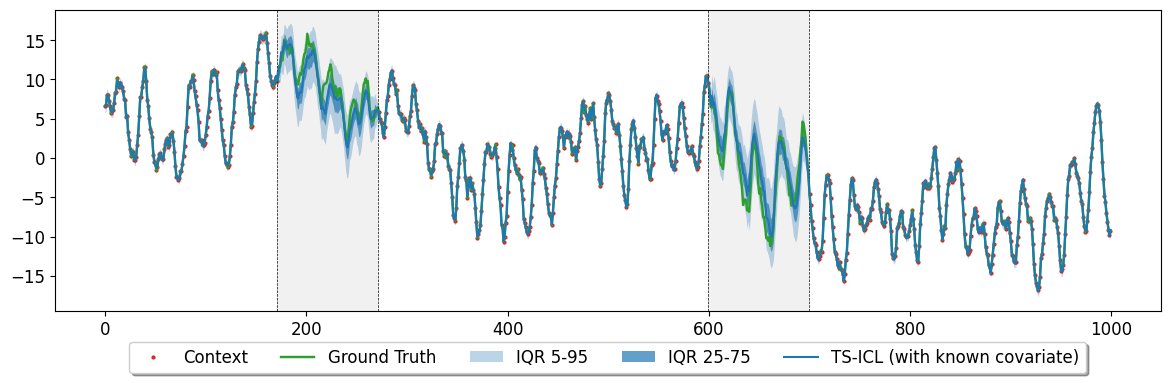

In [8]:
# ── Inference WITH covariate ──────────────────────────────────────────────────
_, batch_q_covar = model.impute(
    inputs          = signal_block,
    batch_size      = 1,
    covars          = weekly_pattern,   # shape [T] → internally broadcast to [1, T, 1]
    device          = device,
    quantile_levels = quantile_levels,
    denormalize     = True
)
pred_block_covar = batch_q_covar.cpu().numpy()   # [T, Q]

fig, ax = plot_sample_imputation(
    quantiles           = pred_block_covar,
    y_true              = np.array(signal),
    y_ctx               = np.array(signal_block),
    show_context_points = True,
    quantile_levels     = quantile_levels,
    plot_iqr            = True,
    model_name          = "TS-ICL (with known covariate)",
    is_blockwise        = True,
    iqr_bands           = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

<a id="sparse-covariate-imputation"></a>

---
#### 1.4. Impute with sparse covariate 

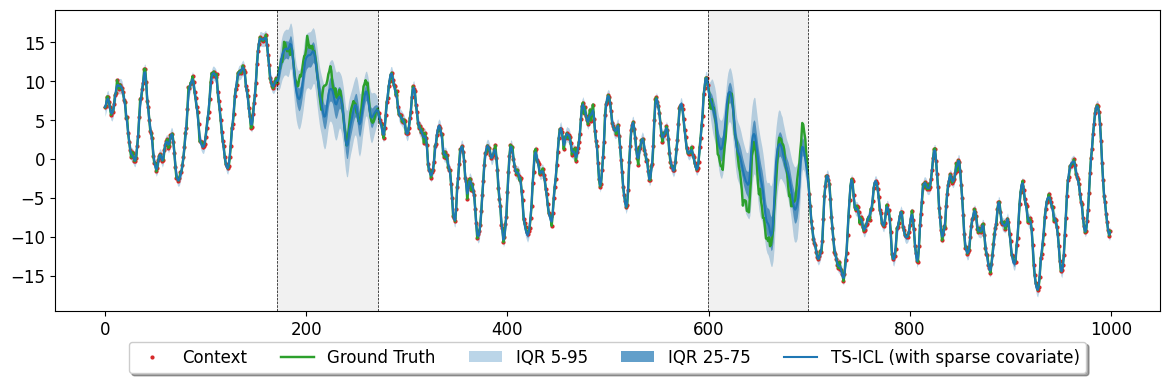

In [9]:
# ── Inference WITH sparse covariate (observed every 3 hours) ────────────────────────────────────────────────

weekly_pattern_masked = weekly_pattern.astype(float)
mask = np.arange(len(weekly_pattern_masked)) % 3 != 0
weekly_pattern_masked[mask] = np.nan

_, batch_q_covar = model.impute(
    inputs              = signal_block,
    batch_size          = 1,
    covars              = weekly_pattern_masked,   # shape [int(T/3)] 
    device              = device,
    quantile_levels     = quantile_levels,
    allow_auto_complete = True,                  # Impute covar then impute target 
    denormalize         = True
)
pred_block_covar_sparse = batch_q_covar.cpu().numpy()   # [T, Q]

fig, ax = plot_sample_imputation(
    quantiles           = pred_block_covar_sparse,
    y_true              = np.array(signal),
    y_ctx               = np.array(signal_block),
    show_context_points = True,
    quantile_levels     = quantile_levels,
    plot_iqr            = True,
    model_name          = "TS-ICL (with sparse covariate)",
    is_blockwise        = True,
    iqr_bands           = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

### Quantitative comparison

The table below evaluates predictions **at the masked positions only** and measures two things:
- **MAE** (↓) — accuracy of the median forecast
- **Mean WQL** (↓) — Weighted Quantile Loss across all quantile levels, assessing both calibration and sharpness

In [10]:
# ── Build quantile lookup ─────────────────────────────────────────────────────
q_idx = {q: i for i, q in enumerate(quantile_levels)}

y_true_missing = signal[mask_block]

def block_mae(preds):
    return np.mean(np.abs(y_true_missing - preds[mask_block, q_idx[0.5]]))

def block_wql(preds):
    """
    Computes the Mean Weighted Quantile Loss (WQL) across all quantile levels.
    This version is normalized by the absolute sum of y_true (GluonTS/Amazon Forecast standard).
    At quantile 0.5, it is mathematically equivalent to WAPE.
    """
    wql_per_quantile = []
    sum_y_true = np.sum(np.abs(y_true_missing))
    
    for q in quantile_levels:
        y_pred = preds[mask_block, q_idx[q]]
        error = y_true_missing - y_pred
        
        # Compute Pinball Loss for the specific quantile q
        pinball_loss = np.maximum(q * error, (q - 1) * error)
        
        # Compute WQL for this specific quantile
        wql_q = 2 * np.sum(pinball_loss) / sum_y_true
        wql_per_quantile.append(wql_q)
        
    # Return the average WQL across all quantiles
    return np.mean(wql_per_quantile)

# ── Metric Computation ────────────────────────────────────────────────────────
mae_no     = block_mae(pred_block_no_covar)
mae_co     = block_mae(pred_block_covar)
mae_sparse = block_mae(pred_block_covar_sparse)

wql_no     = block_wql(pred_block_no_covar)
wql_co     = block_wql(pred_block_covar)
wql_sparse = block_wql(pred_block_covar_sparse)

# ── Output Results ────────────────────────────────────────────────────────────
col1_w, col2_w, col3_w, col4_w = 20, 16, 18, 20

header = f"{'Metric':<{col1_w}} {'No covariate':>{col2_w}} {' With known covariate':>{col3_w}} {'   With sparse covariate':>{col4_w}}"
print(header)
print("─" * (len(header) + 12)) 

# MAE
check_co = '✅' if mae_co < mae_no else '⚠️'
check_sparse = '✅' if mae_sparse < mae_no else '⚠️'
print(f"{'MAE (↓)':<{col1_w}} {mae_no:>{col2_w}.4f} {mae_co:>{col3_w}.4f} {check_co} {mae_sparse:>{col4_w}.4f} {check_sparse}")

# Mean WQL
check_wql_co = '✅' if wql_co < wql_no else '⚠️'
check_wql_sparse = '✅' if wql_sparse < wql_no else '⚠️'
print(f"{'Mean WQL (↓)':<{col1_w}} {wql_no:>{col2_w}.4f} {wql_co:>{col3_w}.4f} {check_wql_co} {wql_sparse:>{col4_w}.4f} {check_wql_sparse}")

Metric                   No covariate  With known covariate    With sparse covariate
────────────────────────────────────────────────────────────────────────────────────────────────
MAE (↓)                        2.4506             1.2911 ✅               1.3555 ✅
Mean WQL (↓)                   0.1991             0.1054 ✅               0.1129 ✅


#### What the numbers show

The results show a clear improvement when including exogenous features:

* **Fully known (`With known covariate`):** Providing complete covariate information across the entire window yields the highest performance, drastically reducing both **MAE** and **Mean WQL**. 
* **Sparse availability (`With sparse covariate`):** Even when observed only every 3 timesteps (with `NaN`s in between), the covariate remains highly effective. It delivers gains nearly on par with the fully known version, significantly outperforming the baseline.

#### A note on covariate availability

TS-ICL accommodates flexible covariate patterns. The `covars` tensor can span:
* **The full window** (context + missing region) — The most informative case.
* **Context only** (covariate unknown inside the gap) — Still beneficial.
* **A subset of timesteps** — Pass `NaN` for unobserved positions; the model natively handles sparse signals and (if `allow_auto_complete = True`) can autocomplete the covariate before target inference.

To pass **multiple covariates**, stack them along the last dimension:
```python
# Two covariates: shape [T, 2]
covar_2 = np.random.randn(T)
covars  = np.stack([weekly_pattern, covar_2], axis=-1)
```

<a id="output-format"></a>

---
## Part 2 — Understanding the Output Format

The model returns predictions at **all** T timesteps (both observed and missing). In practice you evaluate only at the missing positions, but having predictions everywhere lets you use the full predictive distribution for downstream tasks such as anomaly scoring or uncertainty-aware control.

### Quantile indexing and calibration check

In [11]:
# ── Inspect a single-series output from the pointwise experiment ──────────────

print(f"Shape: {pred_quantiles.shape}  →  {pred_quantiles.shape[0]} timesteps × {pred_quantiles.shape[1]} quantiles")

print("\nQuantile levels and column indices:")
for q, idx in q_idx.items():
    print(f"  [{idx:2d}]  Q{int(q*100):02d}  →  value at t=100: {pred_quantiles[100, idx]:.3f}")

Shape: (1000, 13)  →  1000 timesteps × 13 quantiles

Quantile levels and column indices:
  [ 0]  Q01  →  value at t=100: 1.634
  [ 1]  Q05  →  value at t=100: 2.047
  [ 2]  Q10  →  value at t=100: 2.249
  [ 3]  Q20  →  value at t=100: 2.478
  [ 4]  Q25  →  value at t=100: 2.562
  [ 5]  Q30  →  value at t=100: 2.639
  [ 6]  Q50  →  value at t=100: 2.895
  [ 7]  Q70  →  value at t=100: 3.143
  [ 8]  Q75  →  value at t=100: 3.219
  [ 9]  Q80  →  value at t=100: 3.300
  [10]  Q90  →  value at t=100: 3.551
  [11]  Q95  →  value at t=100: 3.767
  [12]  Q99  →  value at t=100: 4.166


In [12]:
# ── Calibration check at the masked (missing) positions ──────────────────────
y_true = signal

mae = np.mean(np.abs(y_true[mask_point] - pred_quantiles[mask_point, q_idx[0.5]]))

# Empirical coverage should match the nominal quantile level for a calibrated model
cov_80 = np.mean(
    (y_true[mask_point] >= pred_quantiles[mask_point, q_idx[0.10]]) &
    (y_true[mask_point] <= pred_quantiles[mask_point, q_idx[0.90]])
)
cov_50 = np.mean(
    (y_true[mask_point] >= pred_quantiles[mask_point, q_idx[0.25]]) &
    (y_true[mask_point] <= pred_quantiles[mask_point, q_idx[0.75]])
)

print(f"MAE at missing positions  : {mae:.4f}")
print(f"80% interval coverage     : {100 * cov_80:.1f}%   (nominal: 80%)")
print(f"50% interval coverage     : {100 * cov_50:.1f}%   (nominal: 50%)")
print()
print("Coverage close to the nominal level indicates well-calibrated predictions.")

MAE at missing positions  : 0.5325
80% interval coverage     : 80.1%   (nominal: 80%)
50% interval coverage     : 46.7%   (nominal: 50%)

Coverage close to the nominal level indicates well-calibrated predictions.


<a id="batch-processing"></a>

---
## Part 3 — Batch Processing

Stack multiple time series into a single `[N, T, 1]` tensor to process them in one call. The `batch_size` argument controls how many series pass through the model per forward pass — reduce it if you run out of GPU memory.

> **Variable-length series:** if your series have different lengths, pass a *list* of `[T_i, 1]` tensors instead of a stacked tensor. The model handles variable lengths natively.

In [13]:
N          = 8
rng_batch  = np.random.default_rng(99)
phases     = rng_batch.uniform(0, 2 * np.pi, size=N)
t_batch    = np.arange(T, dtype=float)           # 1-D array, length T

batch_signals = np.stack([
    2.0 * np.sin(2 * np.pi * t_batch / 24 + phases[i])
    + 0.4 * np.sin(2 * np.pi * t_batch / 168)
    for i in range(N)
], axis=0)   # [N, T]

# Independent 50% pointwise mask per series
batch_masked = batch_signals.copy()
for i in range(N):
    idx_m = rng_batch.random(T) < 0.50
    batch_masked[i, idx_m] = np.nan

# ── Batch inference ───────────────────────────────────────────────────────────
batch_p_all, batch_q_all = model.impute(
    inputs          = torch.tensor(batch_masked, dtype=torch.float32).unsqueeze(-1),  # [N, T, 1]
    batch_size      = 8,           # process up to 8 series per forward pass
    device          = device,
    quantile_levels = quantile_levels,
    denormalize     = True
)
preds_all_q = batch_q_all.squeeze(1).cpu().numpy()   # [N, T, Q]
print(f"Batch output shape: {preds_all_q.shape}  →  {N} series × {T} timesteps × {len(quantile_levels)} quantiles")

Batch output shape: (8, 1000, 13)  →  8 series × 1000 timesteps × 13 quantiles


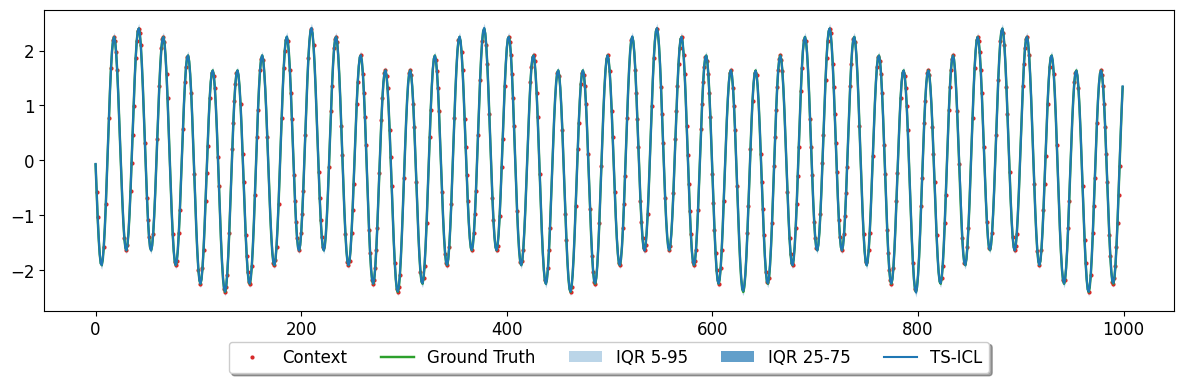

In [14]:
# ── Plot the first series in the batch ───────────────────────────────────────
s = 0
fig, ax = plot_sample_imputation(
    quantiles           = preds_all_q[s],
    y_true              = batch_signals[s].squeeze(),
    y_ctx               = batch_masked[s].squeeze(),
    show_context_points = True,
    quantile_levels     = quantile_levels,
    plot_iqr            = True,
    model_name          = "TS-ICL",
    iqr_bands           = ((0.05, 0.95), (0.25, 0.75))
)
plt.show()
plt.close()

<a id="tips-practices"></a>

---
## Part 4 - Tips & Best Practices

### Details on `.impute` method's arguments

The `.impute` method fills in missing values (`NaN`) within target time series. Below is the structured breakdown of its configuration parameters, input data structures, and expected outputs.

---

#### Configuration Parameters

| Parameter | Type | Default | Description |
| --- | --- | --- | --- |
| **`batch_size`** | `int` | `64` | The batch size used during the inference run. |
| **`quantile_levels`** | `List[float]` | `[0.1, ..., 0.9]` | Quantile levels to compute. Must be a subset of `[0.01, 0.02, ..., 0.99]`. |
| **`device`** | `torch.device` | `cpu` | Target device for execution (e.g., `'cuda'`, `'cpu'`). |
| **`denormalize`** | `bool` | `True` | Whether to return values denormalized in original data space (`True`) or keep them z-normalized (`False`). |
| **`point_estimator`** | `Literal['mean', 'median']` | `'mean'` | Sets the pointwise estimator either as the average of all quantiles (`'mean'`) or as the 0.5 quantile (`'median'`). |
| **`allow_auto_complete`** | `bool` | `False` | If `True`, missing values within the covariates themselves are imputed first before using them to reconstruct the target time series. |
| **`replace_by_gt`** | `bool` | `False` | The method natively reconstructs the full series. If set to `True`, reconstructed values are overwritten by ground truth observations where available. |
| **`squeeze_output`** | `bool` | `True` | If `True`, removes all unit dimensions (`1`) from the final output tensors. |

---

#### Input Data Structures

#### `inputs`

The target time series containing missing values (`NaN`) to be filled. Accepts the following formats and shapes:

* **Multi-dimensional array-like (`torch.Tensor` or `np.ndarray`):**
* **1D:** `(context_length,)`
* **2D:** `(batch, context_length)`
* **3D:** `(batch, context_length, num_variates)` where `num_variates >= 1`.


* **List of array-likes (`List[Tensor | ndarray]`):** Each element can be 1D or 2D.
* **1D:** `(context_length,)`
* **2D:** `(context_length, num_variates)`
* *Note: `context_length` can vary across list elements, but `num_variates` must remain identical.*


* **pandas DataFrame (`pd.DataFrame`):** Must be 2-dimensional with shape `(batch, context_length)`.

#### `covars` *(Optional)*

Optional exogenous features used to support the imputation of `inputs`. Must be aligned on the same time grid as `inputs`, but can contain their own arbitrary missing values.

* **Multi-dimensional array-like (`torch.Tensor` or `np.ndarray`):**
* **1D:** `(context_length,)` *(Single covariate)*
* **2D:** `(batch, context_length)` *(Single covariate)*
* **3D:** `(batch, context_length, num_covariates)` where `num_covariates >= 1`.
* **4D:** `(batch, num_covariates, context_length, 1)`


* **List of array-likes (`List[Tensor | ndarray]`):** Each element can be multi-dimensional:
* **1D:** `(context_length,)` *(Single covariate)*
* **2D:** `(context_length, num_covariates)` where `num_covariates >= 1`.
* **3D:** `(context_length, num_covariates, 1)`

---

#### Returns

The method returns a tuple containing `(point_predictions, quantile_predictions)`:

1. **`point_predictions`** (`Tensor` or `List[Tensor]`)
Pointwise reconstructions generated according to the specified `point_estimator`.
* **As a Tensor:** Shape is `(batch, num_variates, context_length, 1)`
* **As a List:** Each tensor element has shape `(num_variates, context_length, 1)`


2. **`quantile_predictions`** (`Tensor` or `List[Tensor]`)
Probabilistic quantile forecasts generated across all specified `quantile_levels`.
* **As a Tensor:** Shape is `(batch, num_variates, context_length, len(quantile_levels))`
* **As a List:** Each tensor element has shape `(num_variates, context_length, len(quantile_levels))`


### Covariate best practices
- **Availability:** covariates can span the full window, the context only, or be partially observed — use `NaN` for unobserved covariate positions.
- **Number:** there is no architectural limit on K. In practice, start with the most physically motivated covariates; adding redundant ones rarely hurts but increases memory.
- **Scale:** covariates are internally normalized, so there is no need to match the scale of the target series.

### Memory & throughput
- **`batch_size`:** reduce to 1–4 if you run out of GPU memory; the bottleneck is the context encoder, not the per-series prediction.
- **Maximum window:** the imputation checkpoint supports up to **T = 4 096** timesteps. For longer series, use a sliding-window approach and stitch the outputs together.
- **Inference speed:** ~6.5 ms per window on an H100 GPU — roughly **50× faster** than Tabular Foundation Models (Table 2 in the paper).

---

This notebook only scratches the surface — TS-ICL's imputation capabilities go well beyond what's shown here. The best way to discover them is to read the [documentation](https://edf-lab.github.io/ts-icl/autoapi/tsicl/pipeline/index.html) and experiment with your own data!